In [ ]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

data = load_breast_cancer()
df = pd.DataFrame(data.data,
columns=data.feature_names)

df['target'] = data.target

print(df.shape)
print(df.head())
print(df.info())

(569, 31)
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0   

In [ ]:
df.isnull().sum()

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y,
test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
classif = classification_report(y_test, y_pred)

print(f"Accuracy Score: {acc * 100:.2f}%")
print(f"Confusion Matrix:\n{cm}")
print(f"Classification Report:\n{classif}")

Accuracy Score: 98.25%
Confusion Matrix:
[[41  1]
 [ 1 71]]
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



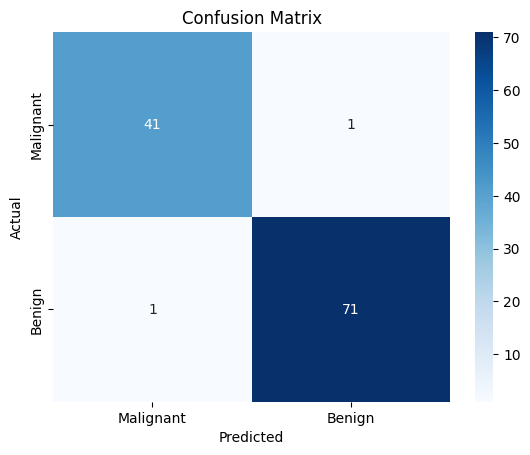

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(cm, fmt='d', annot=True,
cmap="Blues", xticklabels=["Malignant", "Benign"],
yticklabels=["Malignant", "Benign"])

plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

In [ ]:
#Determining the top 5 most important features
coefficients = model.coef_[0]
features = X.columns

#Put them in a dataframe
feature_importance = pd.DataFrame({
'coefficient': coefficients,
'feature': features
})

#Getting the absolute coefficient value
feature_importance['abs_coefficient'] = abs(feature_importance['coefficient'])

#Sort by importance
feature_importance = feature_importance.sort_values(
'abs_coefficient',
ascending=False
)

print("Top 5 most important features:")
print(feature_importance.head(5)[['feature', 'coefficient']])

Top 5 most important features:
                 feature  coefficient
21         worst texture    -1.255088
10          radius error    -1.082965
27  worst concave points    -0.953686
23            worst area    -0.947756
20          worst radius    -0.947616


In [ ]:
new_patients = df.iloc[0:3].drop('target', axis=1).copy()

# Scale them
new_scaled = scaler.transform(new_patients)

# Predict
pred = model.predict(new_scaled)
prob = model.predict_proba(new_scaled)

for i, (p, pr) in enumerate(zip(pred, prob)):
    result = "Malignant" if p == 0 else "Benign"
    confidence = round(pr.max() * 100, 1)
    print(f"Patient {i+1}: {result} ({confidence}% confident)")

Patient 1: Malignant (100.0% confident)
Patient 2: Malignant (100.0% confident)
Patient 3: Malignant (100.0% confident)
